In [11]:
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
pd.read_parquet('hourly_blocks.parquet').iloc[-1,0]

Timestamp('2026-01-19 15:00:00+0000', tz='UTC')

/tmp/ipykernel_79889/1123021638.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d["timestamp"] = pd.to_datetime(d["timestamp"], utc=True, unit = 's')
/tmp/ipykernel_79889/1123021638.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d["tick_norm"] = (d["tickLower"].astype(float) - 0.0) / WINDOW
/tmp/ipykernel_79889/1123021638.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in th

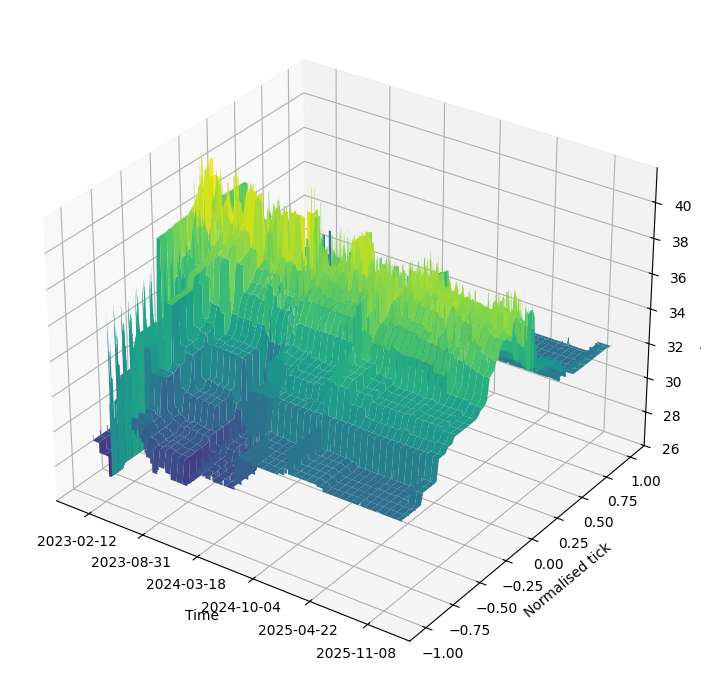

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import datetime

TT = datetime.datetime(2023,1,1,0, tzinfo=datetime.timezone.utc)
d = df[df.hour > TT]
d["timestamp"] = pd.to_datetime(d["timestamp"], utc=True, unit = 's')

# Normalise ticks to [-1, 1] around PEG tick = 0 (i.e., +/-50 ticks => [-1,1])
WINDOW = 50
d["tick_norm"] = (d["tickLower"].astype(float) - 0.0) / WINDOW
d["tick_norm"] = d["tick_norm"].clip(-1, 1)

# Log liquidity (use log1p to handle zeros)
d["logL"] = np.log(d["active_liquidity_L"].astype(float))

# Time x tick grid
surf = (
    d.pivot_table(index="timestamp", columns="tick_norm", values="logL", aggfunc="mean")
     .sort_index()
     .sort_index(axis=1)
)

t = mdates.date2num(surf.index.to_pydatetime())
x = surf.columns.to_numpy(dtype=float)
T, X = np.meshgrid(t, x, indexing="ij")
Z = surf.to_numpy(dtype=float)

fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection="3d")

s = ax.plot_surface(T, X, Z, cmap="viridis", linewidth=0, antialiased=True)

ax.set_ylabel("Normalised tick")
ax.set_xlabel("Time")
ax.set_zlabel("log(liquidity)")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d", tz=mdates.UTC))
# fig.colorbar(s, ax=ax, shrink=0.6, pad=0.1, label="log(L)")
ax.view_init(azim = 305)
plt.tight_layout()
plt.show()

/tmp/ipykernel_79889/2056929702.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d["timestamp"] = pd.to_datetime(d["timestamp"], utc=True)
/tmp/ipykernel_79889/2056929702.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d["x"] = (d["tickLower"].astype(float) / WINDOW_TICKS).clip(-1, 1)
/tmp/ipykernel_79889/2056929702.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docume

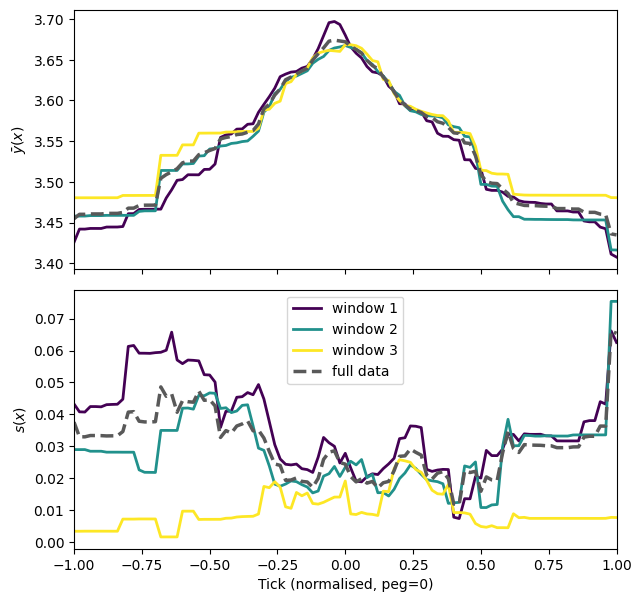

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- inputs ---
WINDOW_TICKS = 50          # +/- 50 ticks around peg
N_WINDOWS = 3            # like the figure (window 1/2/3)
LIQ_COL = "logL"      # liquidity measure in USD (use your preferred column)

d["timestamp"] = pd.to_datetime(d["timestamp"], utc=True)

# normalised tick around PEG tick = 0  -> [-1,1]
d["x"] = (d["tickLower"].astype(float) / WINDOW_TICKS).clip(-1, 1)

# log liquidity curve (stable with zeros)
d["y"] = np.log1p(d[LIQ_COL].astype(float))

# ---- define "windows" over time (equal-size partitions); replace with your own date ranges if desired
d = d.sort_values("timestamp")
d["window"] = pd.qcut(d["timestamp"].view("int64"), q=N_WINDOWS, labels=[f"window {i+1}" for i in range(N_WINDOWS)])

# ---- compute sample mean and std as functions of x (normalised tick)
# full-data stats
full_stats = d.groupby("x", observed=True)["y"].agg(mean="mean", std="std").reset_index()

# per-window stats
win_stats = (d.groupby(["window", "x"], observed=True)["y"]
               .agg(mean="mean", std="std")
               .reset_index())

# ---- plot (layout like the figure but for ONE pool: mean on top, std on bottom)
colors = ["#440154", "#21918c", "#fde725"]  # close to viridis endpoints/mid

fig, (ax_mean, ax_std) = plt.subplots(
    2, 1, figsize=(7, 7), sharex=True, gridspec_kw={"hspace": 0.08}
)

# windows
for i, w in enumerate(sorted(win_stats["window"].unique())):
    tmp = win_stats[win_stats["window"] == w].sort_values("x")
    ax_mean.plot(tmp["x"], tmp["mean"], lw=2, color=colors[i % len(colors)], label=w)
    ax_std.plot(tmp["x"], tmp["std"],  lw=2, color=colors[i % len(colors)], label=w)

# full data (dashed black/grey)
full_stats = full_stats.sort_values("x")
ax_mean.plot(full_stats["x"], full_stats["mean"], "--", lw=2.5, color="0.35", label="full data")
ax_std.plot(full_stats["x"], full_stats["std"],  "--", lw=2.5, color="0.35", label="full data")

# styling
ax_mean.set_ylabel(r"$\bar{y}(x)$")
ax_std.set_ylabel(r"$s(x)$")
ax_std.set_xlabel("Tick (normalised, peg=0)")

ax_mean.set_xlim(-1, 1)
ax_mean.grid(False)
ax_std.grid(False)
ax_std.legend(loc="best", frameon=True)

plt.tight_layout()
plt.show()

/tmp/ipykernel_79889/4042682461.py:115: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


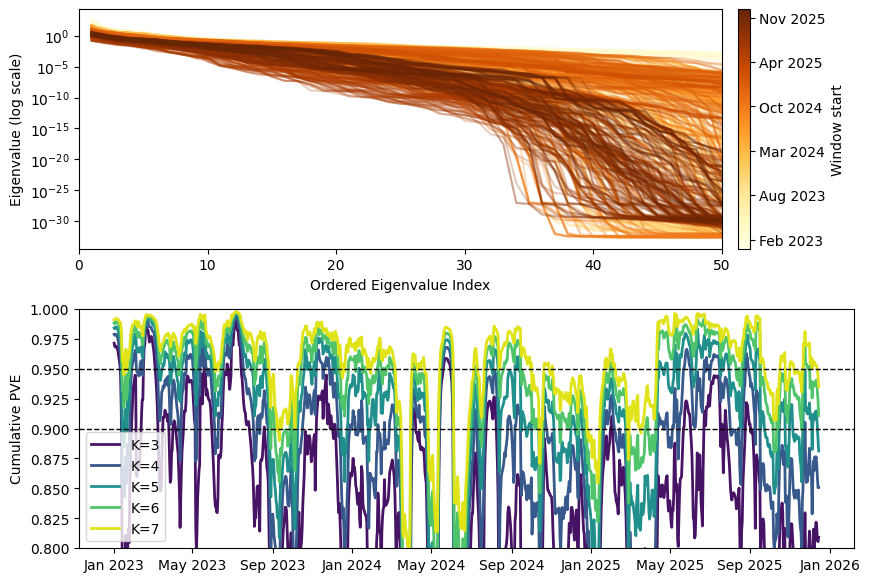

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# ---------------------------
# 1) Build the log-liquidity curve matrix Y(t, x)
# ---------------------------
WINDOW_TICKS = 50                # +/- 50 ticks around PEG tick=0
LIQ_COL = "active_liquidity_L"            # liquidity measure
T = 600                          # rolling window length (as in the figure)
STEP = 24                       # advance the rolling window by STEP timestamps (set e.g. 24 for daily)
KS = [3, 4, 5, 6, 7]             # ranks for CPVE curves



# keep only the +/- window around peg tick=0
d = d[(d["tickLower"] >= -WINDOW_TICKS) & (d["tickLower"] <= WINDOW_TICKS)].copy()

# matrix: rows=time, cols=tickLower, values=liquidity
Y = (d.pivot_table(index="timestamp", columns="tickLower", values=LIQ_COL, aggfunc="sum")
       .sort_index()
       .sort_index(axis=1))

# interpret missing ticks as 0 liquidity
Y = Y.fillna(0.0)

# log-liquidity curve
Ylog = np.log(Y)

# normalized tick axis in [-1, 1]
tick_lower = Ylog.columns.to_numpy(dtype=float)
x_norm = tick_lower / WINDOW_TICKS  # peg tick = 0

# ---------------------------
# 2) Rolling-window PCA
#    PCA is done across ticks (variables), using time samples within each window.
# ---------------------------
def rolling_pca_eigs_and_cpve(Ylog: pd.DataFrame, T=400, step=1, Ks=(3,4,5,6,7)):
    times = Ylog.index
    Xall = Ylog.to_numpy(dtype=float)
    n, p = Xall.shape

    starts, eigs_list, cpve_dict = [], [], {K: [] for K in Ks}

    for s in range(0, n - T + 1, step):
        X = Xall[s:s+T, :]                      # (T, p)
        X = X - X.mean(axis=0, keepdims=True)   # center columns (ticks)

        # SVD: eigenvalues of covariance = S^2/(T-1), already sorted descending
        _, S, _ = np.linalg.svd(X, full_matrices=False)
        eigs = (S**2) / (T - 1)

        starts.append(times[s])
        eigs_list.append(eigs)

        c = np.cumsum(eigs) / np.sum(eigs)
        for K in Ks:
            cpve_dict[K].append(c[min(K-1, len(c)-1)])

    starts = pd.to_datetime(starts, utc=True)
    eigs_arr = np.vstack(eigs_list)  # (n_windows, p)
    cpve = {K: np.array(v) for K, v in cpve_dict.items()}
    return starts, eigs_arr, cpve

t_start, eigs_arr, cpve = rolling_pca_eigs_and_cpve(Ylog, T=T, step=STEP, Ks=KS)

# ---------------------------
# 3) Plot (single pool): top eigenvalue spectra (log-scale), bottom CPVE vs window start time
# ---------------------------
fig = plt.figure(figsize=(10, 7))
gs = fig.add_gridspec(2, 1, height_ratios=[1, 1], hspace=0.25)
ax_top = fig.add_subplot(gs[0, 0])
ax_bot = fig.add_subplot(gs[1, 0])

# color by window start date (lighter=earlier, darker=later)
t_num = mdates.date2num(t_start.to_pydatetime())
norm = Normalize(vmin=t_num.min(), vmax=t_num.max())
cmap = plt.cm.YlOrBr
sm = ScalarMappable(norm=norm, cmap=cmap)

# --- top: ordered eigenvalues for each rolling window
p = eigs_arr.shape[1]
idx = np.arange(1, p + 1)

for i in range(eigs_arr.shape[0]):
    ax_top.plot(idx[:50], eigs_arr[i][:50], color=cmap(norm(t_num[i])), lw=1.5, alpha=0.25)

ax_top.set_yscale("log")
ax_top.set_ylabel("Eigenvalue (log scale)")
ax_top.set_xlabel("Ordered Eigenvalue Index")
ax_top.set_xlim(0, 50)

# colorbar with date formatting
cbar = fig.colorbar(sm, ax=ax_top, pad=0.02)
cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter("%b %Y", tz=mdates.UTC))
cbar.set_label("Window start")

# --- bottom: CPVE for K = 3..7
K_colors = plt.cm.viridis(np.linspace(0.05, 0.95, len(KS)))
for K, col in zip(KS, K_colors):
    ax_bot.plot(t_start, cpve[K], lw=2.0, color=col, label=f"K={K}")

# dashed reference lines like the paper-style plots
ax_bot.axhline(0.90, color="k", ls="--", lw=1)
ax_bot.axhline(0.95, color="k", ls="--", lw=1)

ax_bot.set_ylim(0.80, 1.00)
ax_bot.set_ylabel("Cumulative PVE")
ax_bot.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y", tz=mdates.UTC))
ax_bot.legend(loc="best", frameon=True)

plt.tight_layout()
plt.show()